In [19]:
from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv

In [20]:
load_dotenv()

True

In [21]:
model=ChatGoogleGenerativeAI(model="gemini-3.5-flash",temperature=0.7)

In [22]:
class Joke(TypedDict):
    topic:str
    joke:str
    explanation:str

In [23]:
def gen_joke(state:Joke)->Joke:
    joke= model.invoke(f"Tell me a joke about {state['topic']} ")
    return {'joke':joke}

In [24]:
def explain_joke(state:Joke)->Joke:
    explanation=model.invoke(f"Explain the joke: {state['joke']}")
    return {'explanation':explanation}

In [25]:
from langgraph.checkpoint.memory import InMemorySaver

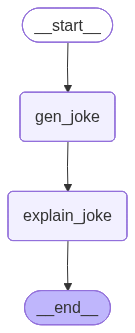

In [26]:
graph=StateGraph(Joke)
graph.add_node('gen_joke',gen_joke)
graph.add_node('explain_joke',explain_joke)

graph.add_edge(START,'gen_joke')
graph.add_edge('gen_joke','explain_joke')
graph.add_edge('explain_joke',END)

checkpointer=InMemorySaver()
workflow=graph.compile(checkpointer=checkpointer)
workflow



In [27]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': AIMessage(content=[{'type': 'text', 'text': 'How do you fix a broken pizza?\n\nWith **tomato paste**!', 'extras': {'signature': 'EtcYCtQYAQw51scDIp5JT35+HvcrAv7izFuhZOE1qlcVcEqh6Ut8ypPtCV+XT5OW+j0HUN/vkEUWbHFQJh0Xbm1Wj8N1L11ZrivN3xoKIzCjzB7H8LYM/FIEq5AgONfd+cAkPbbXyLP22FYyxTKhvYinleg+inVeQKg5EBRF8z/46X5XsZJ6HJxw2Xrs79ZJ1LlwDqx8JIv0cB8GPZxRsdqBhSjGpHPyoN4w822kCTfeNkOkmb39efHo7PwU0BiQW/fPYvCh8+gsybOJFBDxTsr/OMhYrm+dYHDGfcVhkiGjvQKAGQumqWFE4OQtdSed5aRgD83mcj5CdWXZxVvw1fr/jeQ8eKq2p1vUbTl03HkGgASp+Tw6rVlp4DijzyPQm1wQGhGW7b98Y9AWKv1iCakCrvrqR6J9frRTTd/aX+aIvhM3zMjUuE6pXuhY8DNFGoGhtdeAz6hny8pbn26BcNHDTSyGzeDP3DgKj2RO1rs8AyymBzuyH9H4WI/nrqc6YUSXhR8+7Y4y8LxrxIplo9ulHDJoCTYYjqd+jIoIqXsO722FwsWub39fzhIA2UU6Ew9AXuDTFwCOs5dnglRs+X14g85imKOCRSPEc/VatlQ4u048lqgRnkZ+J5Vm7nMdDsy5ArGCHQabKhgamo4AIC26sY47KibwX8r9IMopjTtC3kiEb+Y3It2bY1TC4yS8IQ5BJNViAevJJD/IvYbm9wLUfeHhjh3mpG/MSymcebypkYBnAIESsZsGCpaifnZNaeSFjlsc7LJ/hT0xkMjG0Y890SVvo9GPZBtc+mGe/vviNGLCuhIq33dx02VU5ux5RJuBuD7RzLF

In [28]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': AIMessage(content=[{'type': 'text', 'text': 'How do you fix a broken pizza?\n\nWith **tomato paste**!', 'extras': {'signature': 'EtcYCtQYAQw51scDIp5JT35+HvcrAv7izFuhZOE1qlcVcEqh6Ut8ypPtCV+XT5OW+j0HUN/vkEUWbHFQJh0Xbm1Wj8N1L11ZrivN3xoKIzCjzB7H8LYM/FIEq5AgONfd+cAkPbbXyLP22FYyxTKhvYinleg+inVeQKg5EBRF8z/46X5XsZJ6HJxw2Xrs79ZJ1LlwDqx8JIv0cB8GPZxRsdqBhSjGpHPyoN4w822kCTfeNkOkmb39efHo7PwU0BiQW/fPYvCh8+gsybOJFBDxTsr/OMhYrm+dYHDGfcVhkiGjvQKAGQumqWFE4OQtdSed5aRgD83mcj5CdWXZxVvw1fr/jeQ8eKq2p1vUbTl03HkGgASp+Tw6rVlp4DijzyPQm1wQGhGW7b98Y9AWKv1iCakCrvrqR6J9frRTTd/aX+aIvhM3zMjUuE6pXuhY8DNFGoGhtdeAz6hny8pbn26BcNHDTSyGzeDP3DgKj2RO1rs8AyymBzuyH9H4WI/nrqc6YUSXhR8+7Y4y8LxrxIplo9ulHDJoCTYYjqd+jIoIqXsO722FwsWub39fzhIA2UU6Ew9AXuDTFwCOs5dnglRs+X14g85imKOCRSPEc/VatlQ4u048lqgRnkZ+J5Vm7nMdDsy5ArGCHQabKhgamo4AIC26sY47KibwX8r9IMopjTtC3kiEb+Y3It2bY1TC4yS8IQ5BJNViAevJJD/IvYbm9wLUfeHhjh3mpG/MSymcebypkYBnAIESsZsGCpaifnZNaeSFjlsc7LJ/hT0xkMjG0Y890SVvo9GPZBtc+mGe/vviNGLCuhIq33d

In [29]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': AIMessage(content=[{'type': 'text', 'text': 'How do you fix a broken pizza?\n\nWith **tomato paste**!', 'extras': {'signature': 'EtcYCtQYAQw51scDIp5JT35+HvcrAv7izFuhZOE1qlcVcEqh6Ut8ypPtCV+XT5OW+j0HUN/vkEUWbHFQJh0Xbm1Wj8N1L11ZrivN3xoKIzCjzB7H8LYM/FIEq5AgONfd+cAkPbbXyLP22FYyxTKhvYinleg+inVeQKg5EBRF8z/46X5XsZJ6HJxw2Xrs79ZJ1LlwDqx8JIv0cB8GPZxRsdqBhSjGpHPyoN4w822kCTfeNkOkmb39efHo7PwU0BiQW/fPYvCh8+gsybOJFBDxTsr/OMhYrm+dYHDGfcVhkiGjvQKAGQumqWFE4OQtdSed5aRgD83mcj5CdWXZxVvw1fr/jeQ8eKq2p1vUbTl03HkGgASp+Tw6rVlp4DijzyPQm1wQGhGW7b98Y9AWKv1iCakCrvrqR6J9frRTTd/aX+aIvhM3zMjUuE6pXuhY8DNFGoGhtdeAz6hny8pbn26BcNHDTSyGzeDP3DgKj2RO1rs8AyymBzuyH9H4WI/nrqc6YUSXhR8+7Y4y8LxrxIplo9ulHDJoCTYYjqd+jIoIqXsO722FwsWub39fzhIA2UU6Ew9AXuDTFwCOs5dnglRs+X14g85imKOCRSPEc/VatlQ4u048lqgRnkZ+J5Vm7nMdDsy5ArGCHQabKhgamo4AIC26sY47KibwX8r9IMopjTtC3kiEb+Y3It2bY1TC4yS8IQ5BJNViAevJJD/IvYbm9wLUfeHhjh3mpG/MSymcebypkYBnAIESsZsGCpaifnZNaeSFjlsc7LJ/hT0xkMjG0Y890SVvo9GPZBtc+mGe/vviNGLCuhIq33

In [30]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': AIMessage(content=[{'type': 'text', 'text': 'What do you call a fake noodle?\n\nAn **impasta**!', 'extras': {'signature': 'EpsQCpgQAQw51sc4nibESTaCdVXXIIbu42SdrnrEaDLpMoTm44lQ5ViVuXl5+4L0xT9INF2ueZ7lk2a2r2DEH59yi6GKQdfQTvIm1UtAZtGr03myxRlSwduy1zocBiBU/mML/vvTrvoTc5rfW/3AszJAtdWmQSzpZCzWuXvcAXrSv3q493LYI8phkuQk73fFbY45J8ivHD4An/xFoSUhQCkuf66Rn5GGFAJNjAD4tcz4rZZWppEGvrIilXN2OzUjficuodbdzXOoT+myylYGdLfZ+fx5pOGqt8sKMoo3yOR3mKRB9oSZOsfLMSUiKXGYKi+4/IWV7cQiXFJUaOvzeB1kt611IxyNyqEjwatdJWnQE2UenIxhkncIZqvtWd0ZAGAo60f26qqQda9QGUJW3ARkik9tUFjMcLzGte1WWRrOVM51xWvjNkmuDX7sKXBYm1zadAWxaGBx53ZCyBHcOAuYgw/p+GZML4WBCERt5OiSdpaf6OBQH8o3GsZ437UaWPWAOEGIbmdZSgGHaZ8PDFC/DyAd2YaAKI7sQZyCyzgc48kERCJZeJ44uXyLxTTuVMgRiFPytcZAgQwCL8TiTGpzGz+/8wvtBgTyRZ+Hqx1k8vJZwR8l/WfO8ko9p1w5Q0VOlXm5NdppVcorLwI2rl6AAvCSgLkv5GCAhqW/3hox9JthgEk3+SeBj6qk5Beet7ndNYc51SdEx071ZxXsmilCFU8m7/1NqqTlgHSKm2vf7J5tuT+7IE9wgPMUkMO5xdayFjGtCsdfk7owDl+lwkGZYumocYqDLzp7+qYKQG3/NyzSYXUNfkO8zu48HoS1mPjGorQ/YQrM+8iL5

In [31]:

list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': AIMessage(content=[{'type': 'text', 'text': 'How do you fix a broken pizza?\n\nWith **tomato paste**!', 'extras': {'signature': 'EtcYCtQYAQw51scDIp5JT35+HvcrAv7izFuhZOE1qlcVcEqh6Ut8ypPtCV+XT5OW+j0HUN/vkEUWbHFQJh0Xbm1Wj8N1L11ZrivN3xoKIzCjzB7H8LYM/FIEq5AgONfd+cAkPbbXyLP22FYyxTKhvYinleg+inVeQKg5EBRF8z/46X5XsZJ6HJxw2Xrs79ZJ1LlwDqx8JIv0cB8GPZxRsdqBhSjGpHPyoN4w822kCTfeNkOkmb39efHo7PwU0BiQW/fPYvCh8+gsybOJFBDxTsr/OMhYrm+dYHDGfcVhkiGjvQKAGQumqWFE4OQtdSed5aRgD83mcj5CdWXZxVvw1fr/jeQ8eKq2p1vUbTl03HkGgASp+Tw6rVlp4DijzyPQm1wQGhGW7b98Y9AWKv1iCakCrvrqR6J9frRTTd/aX+aIvhM3zMjUuE6pXuhY8DNFGoGhtdeAz6hny8pbn26BcNHDTSyGzeDP3DgKj2RO1rs8AyymBzuyH9H4WI/nrqc6YUSXhR8+7Y4y8LxrxIplo9ulHDJoCTYYjqd+jIoIqXsO722FwsWub39fzhIA2UU6Ew9AXuDTFwCOs5dnglRs+X14g85imKOCRSPEc/VatlQ4u048lqgRnkZ+J5Vm7nMdDsy5ArGCHQabKhgamo4AIC26sY47KibwX8r9IMopjTtC3kiEb+Y3It2bY1TC4yS8IQ5BJNViAevJJD/IvYbm9wLUfeHhjh3mpG/MSymcebypkYBnAIESsZsGCpaifnZNaeSFjlsc7LJ/hT0xkMjG0Y890SVvo9GPZBtc+mGe/vviNGLCuhIq33

In [33]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': AIMessage(content=[{'type': 'text', 'text': 'What do you call a fake noodle?\n\nAn **impasta**!', 'extras': {'signature': 'EpsQCpgQAQw51sc4nibESTaCdVXXIIbu42SdrnrEaDLpMoTm44lQ5ViVuXl5+4L0xT9INF2ueZ7lk2a2r2DEH59yi6GKQdfQTvIm1UtAZtGr03myxRlSwduy1zocBiBU/mML/vvTrvoTc5rfW/3AszJAtdWmQSzpZCzWuXvcAXrSv3q493LYI8phkuQk73fFbY45J8ivHD4An/xFoSUhQCkuf66Rn5GGFAJNjAD4tcz4rZZWppEGvrIilXN2OzUjficuodbdzXOoT+myylYGdLfZ+fx5pOGqt8sKMoo3yOR3mKRB9oSZOsfLMSUiKXGYKi+4/IWV7cQiXFJUaOvzeB1kt611IxyNyqEjwatdJWnQE2UenIxhkncIZqvtWd0ZAGAo60f26qqQda9QGUJW3ARkik9tUFjMcLzGte1WWRrOVM51xWvjNkmuDX7sKXBYm1zadAWxaGBx53ZCyBHcOAuYgw/p+GZML4WBCERt5OiSdpaf6OBQH8o3GsZ437UaWPWAOEGIbmdZSgGHaZ8PDFC/DyAd2YaAKI7sQZyCyzgc48kERCJZeJ44uXyLxTTuVMgRiFPytcZAgQwCL8TiTGpzGz+/8wvtBgTyRZ+Hqx1k8vJZwR8l/WfO8ko9p1w5Q0VOlXm5NdppVcorLwI2rl6AAvCSgLkv5GCAhqW/3hox9JthgEk3+SeBj6qk5Beet7ndNYc51SdEx071ZxXsmilCFU8m7/1NqqTlgHSKm2vf7J5tuT+7IE9wgPMUkMO5xdayFjGtCsdfk7owDl+lwkGZYumocYqDLzp7+qYKQG3/NyzSYXUNfkO8zu48H

# Time Travel

In [34]:
workflow.get_state({'configurable':{'thread_id':'1','checkpoint_id':'1f157bbe-3106-6eec-8002-7c1c9bdd2c58'}})

StateSnapshot(values={'topic': 'pizza', 'joke': AIMessage(content=[{'type': 'text', 'text': 'How do you fix a broken pizza?\n\nWith **tomato paste**!', 'extras': {'signature': 'EtcYCtQYAQw51scDIp5JT35+HvcrAv7izFuhZOE1qlcVcEqh6Ut8ypPtCV+XT5OW+j0HUN/vkEUWbHFQJh0Xbm1Wj8N1L11ZrivN3xoKIzCjzB7H8LYM/FIEq5AgONfd+cAkPbbXyLP22FYyxTKhvYinleg+inVeQKg5EBRF8z/46X5XsZJ6HJxw2Xrs79ZJ1LlwDqx8JIv0cB8GPZxRsdqBhSjGpHPyoN4w822kCTfeNkOkmb39efHo7PwU0BiQW/fPYvCh8+gsybOJFBDxTsr/OMhYrm+dYHDGfcVhkiGjvQKAGQumqWFE4OQtdSed5aRgD83mcj5CdWXZxVvw1fr/jeQ8eKq2p1vUbTl03HkGgASp+Tw6rVlp4DijzyPQm1wQGhGW7b98Y9AWKv1iCakCrvrqR6J9frRTTd/aX+aIvhM3zMjUuE6pXuhY8DNFGoGhtdeAz6hny8pbn26BcNHDTSyGzeDP3DgKj2RO1rs8AyymBzuyH9H4WI/nrqc6YUSXhR8+7Y4y8LxrxIplo9ulHDJoCTYYjqd+jIoIqXsO722FwsWub39fzhIA2UU6Ew9AXuDTFwCOs5dnglRs+X14g85imKOCRSPEc/VatlQ4u048lqgRnkZ+J5Vm7nMdDsy5ArGCHQabKhgamo4AIC26sY47KibwX8r9IMopjTtC3kiEb+Y3It2bY1TC4yS8IQ5BJNViAevJJD/IvYbm9wLUfeHhjh3mpG/MSymcebypkYBnAIESsZsGCpaifnZNaeSFjlsc7LJ/hT0xkMjG0Y890SVvo9GPZBtc+mGe/vviNGLCuhIq33d

In [35]:
workflow.invoke(None,{'configurable':{'thread_id':'1','checkpoint_id':'1f157bbe-3106-6eec-8002-7c1c9bdd2c58'}})

{'topic': 'pizza',
 'joke': AIMessage(content=[{'type': 'text', 'text': 'How do you fix a broken pizza?\n\nWith **tomato paste**!', 'extras': {'signature': 'EtcYCtQYAQw51scDIp5JT35+HvcrAv7izFuhZOE1qlcVcEqh6Ut8ypPtCV+XT5OW+j0HUN/vkEUWbHFQJh0Xbm1Wj8N1L11ZrivN3xoKIzCjzB7H8LYM/FIEq5AgONfd+cAkPbbXyLP22FYyxTKhvYinleg+inVeQKg5EBRF8z/46X5XsZJ6HJxw2Xrs79ZJ1LlwDqx8JIv0cB8GPZxRsdqBhSjGpHPyoN4w822kCTfeNkOkmb39efHo7PwU0BiQW/fPYvCh8+gsybOJFBDxTsr/OMhYrm+dYHDGfcVhkiGjvQKAGQumqWFE4OQtdSed5aRgD83mcj5CdWXZxVvw1fr/jeQ8eKq2p1vUbTl03HkGgASp+Tw6rVlp4DijzyPQm1wQGhGW7b98Y9AWKv1iCakCrvrqR6J9frRTTd/aX+aIvhM3zMjUuE6pXuhY8DNFGoGhtdeAz6hny8pbn26BcNHDTSyGzeDP3DgKj2RO1rs8AyymBzuyH9H4WI/nrqc6YUSXhR8+7Y4y8LxrxIplo9ulHDJoCTYYjqd+jIoIqXsO722FwsWub39fzhIA2UU6Ew9AXuDTFwCOs5dnglRs+X14g85imKOCRSPEc/VatlQ4u048lqgRnkZ+J5Vm7nMdDsy5ArGCHQabKhgamo4AIC26sY47KibwX8r9IMopjTtC3kiEb+Y3It2bY1TC4yS8IQ5BJNViAevJJD/IvYbm9wLUfeHhjh3mpG/MSymcebypkYBnAIESsZsGCpaifnZNaeSFjlsc7LJ/hT0xkMjG0Y890SVvo9GPZBtc+mGe/vviNGLCuhIq33dx02VU5ux5RJuBuD7RzLF